# Learning Latent Intent From Observation

**A conservative final project presentation package**  
Prepared for a 5-minute academic-style talk, May 8, 2026.

**Audience:** RL / ML listeners who have not seen this project.  
**Main claim posture:** promising signals and useful contributions, not a solved benchmark.

Use this notebook in two ways:

- The **Slide** sections are the presentation version.
- Concrete interface examples show the low-dimensional state, RGB bridge view, and 5-D action space.
- The **Report expansion notes** under each slide are extra material to reuse in the final writeup.


In [1]:
from pathlib import Path
import csv
import json

from IPython.display import display, Markdown, Image, HTML
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})


def find_repo_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'assets' / 'infom.png').exists() and (candidate / 'AGENTS.md').exists():
            return candidate
    raise RuntimeError(f'Could not find repo root from {start}')

ROOT = find_repo_root()
NOTEBOOK_DIR = ROOT / 'output' / 'jupyter-notebook'
RESULT_ART = NOTEBOOK_DIR / 'artifacts' / 'method-b-ft-collapse-analysis'
PRESENTATION_ART = NOTEBOOK_DIR / 'artifacts' / 'final-project-presentation'
PRESENTATION_ART.mkdir(parents=True, exist_ok=True)
METHOD_A_PRETRAIN_CANDIDATES = [
    ROOT / 'output' / 'latest_compare' / 'method_a_full' / 'runs' / 'state_distilled_method_a_diagnostic' / 'task1_seed0_1000kpre_0kft' / 'pretraining_train.csv',
    NOTEBOOK_DIR / 'cache' / 'state_distilled_method_a_monitor' / 'full' / 'runs' / 'state_distilled_method_a_diagnostic' / 'task1_seed0_1000kpre_0kft' / 'pretraining_train.csv',
]
METHOD_A_PRETRAIN = next((p for p in METHOD_A_PRETRAIN_CANDIDATES if p.exists()), METHOD_A_PRETRAIN_CANDIDATES[-1])
SOURCE_METHOD_LABEL = 'Method ' + 'A'

paths = {
    'InFOM overview image': ROOT / 'assets' / 'infom.png',
    'Aggregate by method': RESULT_ART / 'ft_aggregate_by_method.csv',
    'Aggregate by task': RESULT_ART / 'ft_aggregate_by_method_task.csv',
    'Paper-window by method': RESULT_ART / 'ft_paper_window_by_method.csv',
    'Paper-window by task': RESULT_ART / 'ft_paper_window_by_task.csv',
    'Paper-window metrics': RESULT_ART / 'ft_paper_window_metrics.csv',
    'Eval aligned train metrics': RESULT_ART / 'ft_eval_aligned_train_metrics.csv',
    'Claim readiness': RESULT_ART / 'claim_readiness.csv',
    'Demo summary': RESULT_ART / 'demo_summary.csv',
    'InFOM brief pipeline': PRESENTATION_ART / 'infom_brief_pipeline.png',
    'Observation/action example': PRESENTATION_ART / 'obs_action_example.png',
    'our method algorithm pipeline': PRESENTATION_ART / 'method_a_algorithm_pipeline.png',
    'State/action example table': PRESENTATION_ART / 'state_action_example.csv',
    'our method bridge learning plot': PRESENTATION_ART / 'method_a_bridge_learning.png',
    'our method intent learning plot': PRESENTATION_ART / 'method_a_infom_intent_learning.png',
    'our method success curves': PRESENTATION_ART / 'method_a_success_curves.png',
    'our method task1 mean success curve': PRESENTATION_ART / 'method_a_task1_mean_success_curve.png',
    'our method best vs paper plot': PRESENTATION_ART / 'method_a_best_vs_paper.png',
    'our method presentation summary': PRESENTATION_ART / 'method_a_presentation_summary.csv',
    'our method pretraining summary': PRESENTATION_ART / 'method_a_pretraining_summary.csv',
}


def read_csv(path):
    with open(path, newline='') as f:
        return list(csv.DictReader(f))


def fmt_value(value):
    if value is None:
        return ''
    text = str(value)
    if text == '':
        return ''
    try:
        x = float(text)
    except ValueError:
        return text
    if abs(x) >= 100:
        return f'{x:.1f}'
    if abs(x) >= 10:
        return f'{x:.2f}'
    return f'{x:.3f}'


def markdown_table(rows, columns, headers=None, max_rows=None):
    if headers is None:
        headers = columns
    rows = rows[:max_rows] if max_rows else rows
    header = '| ' + ' | '.join(headers) + ' |'
    sep = '| ' + ' | '.join(['---'] * len(headers)) + ' |'
    body = []
    for row in rows:
        body.append('| ' + ' | '.join(fmt_value(row.get(col, '')) for col in columns) + ' |')
    return '\n'.join([header, sep, *body])


def show_table(rows, columns, headers=None, max_rows=None):
    display(Markdown(markdown_table(rows, columns, headers, max_rows)))


def show_image(path, width=950):
    path = Path(path)
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        display(Markdown(f'**Missing image:** `{path}`'))


def smooth(series, window=15):
    return pd.to_numeric(series, errors='coerce').rolling(window=window, min_periods=1, center=True).mean()


def savefig(fig, path):
    fig.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.close(fig)


def generate_method_a_pretraining_plots():
    if not METHOD_A_PRETRAIN.exists():
        return pd.DataFrame()
    pre = pd.read_csv(METHOD_A_PRETRAIN).sort_values('step')
    x = pre['step'] / 1000.0

    fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.4))
    axes[0].plot(x, smooth(pre['validation/align/align_loss']), color='#2468B2', linewidth=2.4, label='validation RGB-to-state loss')
    axes[0].plot(x, smooth(pre['training/align/align_loss']), color='#8AB6E6', linewidth=1.5, label='train RGB-to-state loss')
    axes[0].axvspan(0, 10, color='#D9E8F5', alpha=0.65, label='alignment warmup')
    axes[0].set_title('RGB bridge learns state latent')
    axes[0].set_xlabel('pretraining step (k)')
    axes[0].set_ylabel('MSE alignment loss')
    axes[0].legend(fontsize=11)

    axes[1].plot(x, smooth(pre['validation/actor_modality/action_cos_rgb_state']), color='#248C46', linewidth=2.4, label='action cosine')
    axes[1].plot(x, smooth(pre['validation/actor_modality/action_mse_rgb_state']), color='#C45A2D', linewidth=2.0, label='action MSE')
    axes[1].axvspan(0, 10, color='#D9E8F5', alpha=0.65)
    axes[1].set_title('Actor agrees across views')
    axes[1].set_xlabel('pretraining step (k)')
    axes[1].set_ylabel('agreement metric')
    axes[1].legend(fontsize=11)
    savefig(fig, paths['our method bridge learning plot'])

    fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.4))
    flow_cols = [
        ('validation/flow_occupancy/flow_matching_loss', 'flow matching'),
        ('validation/flow_occupancy/neg_elbo_loss', 'neg ELBO'),
        ('validation/flow_occupancy/kl_loss', 'KL'),
    ]
    for col, label in flow_cols:
        axes[0].plot(x, smooth(pre[col]), linewidth=2, label=label)
    axes[0].set_yscale('log')
    axes[0].axvspan(0, 10, color='#D9E8F5', alpha=0.65)
    axes[0].set_title('Intent/flow losses fall')
    axes[0].set_xlabel('pretraining step (k)')
    axes[0].set_ylabel('validation loss, log scale')
    axes[0].legend(fontsize=11)

    axes[1].plot(x, smooth(pre['validation/loss/infom_pretraining_loss']), color='#5B3C99', linewidth=2.4, label='validation InFOM loss')
    axes[1].plot(x, smooth(pre['training/loss/infom_pretraining_loss']), color='#B5A7DF', linewidth=1.6, label='train InFOM loss')
    axes[1].axvspan(0, 10, color='#D9E8F5', alpha=0.65)
    axes[1].set_title('InFOM backbone trains')
    axes[1].set_xlabel('pretraining step (k)')
    axes[1].set_ylabel('InFOM pretraining loss')
    axes[1].legend(fontsize=11)
    savefig(fig, paths['our method intent learning plot'])

    summary_rows = []
    for col in [
        'validation/align/align_loss',
        'validation/actor_modality/action_cos_rgb_state',
        'validation/actor_modality/action_mse_rgb_state',
        'validation/flow_occupancy/flow_matching_loss',
        'validation/flow_occupancy/neg_elbo_loss',
        'validation/flow_occupancy/kl_loss',
        'validation/loss/infom_pretraining_loss',
    ]:
        values = pd.to_numeric(pre[col], errors='coerce')
        summary_rows.append({
            'metric': col,
            'first_10_mean': values.head(10).mean(),
            'last_10_mean': values.tail(10).mean(),
            'min': values.min(),
            'max': values.max(),
        })
    pre_summary = pd.DataFrame(summary_rows)
    pre_summary.to_csv(paths['our method pretraining summary'], index=False)
    return pre_summary


def generate_method_a_result_plots():
    paper_path = paths['Paper-window metrics']
    eval_path = paths['Eval aligned train metrics']
    if not paper_path.exists():
        return pd.DataFrame()
    paper = pd.read_csv(paper_path)
    a = paper[paper['method'].eq(SOURCE_METHOD_LABEL)].copy()
    targets = {1: 0.925, 2: 0.784, 3: 0.564, 4: 0.915, 5: 0.700}
    by_task = a.groupby('task').agg(
        n_runs=('run', 'count'),
        paper_window_mean=('paper_window_success', 'mean'),
        paper_window_std=('paper_window_success', 'std'),
        best_mean=('best_success', 'mean'),
        best_max=('best_success', 'max'),
    ).reset_index().sort_values('task')
    by_task['paper_reported_infom'] = by_task['task'].map(targets)
    by_task.to_csv(paths['our method presentation summary'], index=False)

    x = np.arange(len(by_task))
    width = 0.28
    fig, ax = plt.subplots(figsize=(8.0, 3.8))
    ax.bar(x - width/2, by_task['paper_window_mean'], width, label='our method: paper-window mean', color='#2468B2')
    ax.bar(x + width/2, by_task['best_mean'], width, label='our method: best mean', color='#64A46B')
    ax.scatter(x + width/2, by_task['best_max'], color='#0C4B20', s=70, marker='D', label='our method: best seed')
    ax.scatter(x, by_task['paper_reported_infom'], color='#333333', s=95, marker='_', linewidths=3, label='paper-reported InFOM')
    ax.set_xticks(x)
    ax.set_xticklabels([f'task {int(t)}\n(n={int(n)})' for t, n in zip(by_task['task'], by_task['n_runs'])])
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('success rate')
    ax.set_title('Best success vs. paper target')
    ax.legend(ncol=2, loc='upper center', bbox_to_anchor=(0.5, -0.30), frameon=False)
    savefig(fig, paths['our method best vs paper plot'])

    if eval_path.exists():
        ev = pd.read_csv(eval_path)
        ev = ev[ev['method'].eq(SOURCE_METHOD_LABEL) & ev['task'].isin([1, 4])].copy()
        ev['ft_step_k'] = (pd.to_numeric(ev['step'], errors='coerce') - 1_000_000) / 1000.0
        success_col = 'evaluation/success' if 'evaluation/success' in ev.columns else 'evaluation/episode.success'
        fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.5), sharey=True)
        for ax, task in zip(axes, [1, 4]):
            gtask = ev[ev['task'].eq(task)].sort_values('step')
            for seed, g in gtask.groupby('seed'):
                ax.plot(g['ft_step_k'], pd.to_numeric(g[success_col], errors='coerce'), marker='o', linewidth=1.5, markersize=3.2, alpha=0.78, label=f'seed {int(seed)}')
            ax.axvspan(400, 500, color='#F4D8AA', alpha=0.45, label='paper window' if task == 1 else None)
            ax.set_title(f'Our method: task {task}')
            ax.set_xlabel('fine-tuning step (k)')
            ax.set_ylim(-0.03, 1.03)
            ax.grid(True, alpha=0.35)
        axes[0].set_ylabel('eval success')
        axes[0].legend(fontsize=9, ncol=2)
        axes[1].legend(fontsize=9, ncol=2)
        savefig(fig, paths['our method success curves'])

        task1 = ev[ev['task'].eq(1)].copy()
        if not task1.empty:
            grouped = task1.groupby('ft_step_k')[success_col].agg(['mean', 'std', 'count']).reset_index()
            grouped['sem'] = grouped['std'] / np.sqrt(grouped['count'].clip(lower=1))
            fig, ax = plt.subplots(figsize=(6.4, 3.6))
            ax.plot(grouped['ft_step_k'], grouped['mean'], marker='o', color='#2468B2', linewidth=2.6, label='mean across seeds')
            ax.fill_between(
                grouped['ft_step_k'],
                (grouped['mean'] - grouped['sem']).clip(lower=0),
                (grouped['mean'] + grouped['sem']).clip(upper=1),
                color='#2468B2',
                alpha=0.18,
                label='±1 SEM',
            )
            ax.axvspan(400, 500, color='#F4D8AA', alpha=0.45, label='paper window')
            ax.set_title('Our method: task 1 success')
            ax.set_xlabel('fine-tuning step (k)')
            ax.set_ylabel('mean eval success')
            ax.set_ylim(-0.03, 1.03)
            ax.legend(loc='upper left', frameon=True)
            savefig(fig, paths['our method task1 mean success curve'])
    return by_task

pretraining_summary_df = generate_method_a_pretraining_plots()
method_a_summary_df = generate_method_a_result_plots()

if METHOD_A_PRETRAIN.exists():
    pretrain_steps = pd.read_csv(METHOD_A_PRETRAIN, usecols=['step'])['step']
    display(Markdown(
        f'Pretraining diagnostic source: `{METHOD_A_PRETRAIN.relative_to(ROOT)}`. '
        f'This locally synced metric log reaches {int(pretrain_steps.max()):,} / 1,000,000 updates; FT logs show the restored pretraining checkpoint itself was at step 1,000,000.'
    ))

status_rows = [
    {
        'artifact': name,
        'path': str(path.relative_to(ROOT)),
        'exists': path.exists(),
    }
    for name, path in paths.items()
]
show_table(status_rows, ['artifact', 'exists', 'path'], ['Artifact', 'Exists', 'Path'])


Pretraining diagnostic source: `output/latest_compare/method_a_full/runs/state_distilled_method_a_diagnostic/task1_seed0_1000kpre_0kft/pretraining_train.csv`. This locally synced metric log reaches 608,000 / 1,000,000 updates; FT logs show the restored pretraining checkpoint itself was at step 1,000,000.

| Artifact | Exists | Path |
| --- | --- | --- |
| InFOM overview image | True | assets/infom.png |
| Aggregate by method | True | output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis/ft_aggregate_by_method.csv |
| Aggregate by task | True | output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis/ft_aggregate_by_method_task.csv |
| Paper-window by method | True | output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis/ft_paper_window_by_method.csv |
| Paper-window by task | True | output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis/ft_paper_window_by_task.csv |
| Paper-window metrics | True | output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis/ft_paper_window_metrics.csv |
| Eval aligned train metrics | True | output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis/ft_eval_aligned_train_metrics.csv |
| Claim readiness | True | output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis/claim_readiness.csv |
| Demo summary | True | output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis/demo_summary.csv |
| InFOM brief pipeline | True | output/jupyter-notebook/artifacts/final-project-presentation/infom_brief_pipeline.png |
| Observation/action example | True | output/jupyter-notebook/artifacts/final-project-presentation/obs_action_example.png |
| our method algorithm pipeline | True | output/jupyter-notebook/artifacts/final-project-presentation/method_a_algorithm_pipeline.png |
| State/action example table | True | output/jupyter-notebook/artifacts/final-project-presentation/state_action_example.csv |
| our method bridge learning plot | True | output/jupyter-notebook/artifacts/final-project-presentation/method_a_bridge_learning.png |
| our method intent learning plot | True | output/jupyter-notebook/artifacts/final-project-presentation/method_a_infom_intent_learning.png |
| our method success curves | True | output/jupyter-notebook/artifacts/final-project-presentation/method_a_success_curves.png |
| our method task1 mean success curve | True | output/jupyter-notebook/artifacts/final-project-presentation/method_a_task1_mean_success_curve.png |
| our method best vs paper plot | True | output/jupyter-notebook/artifacts/final-project-presentation/method_a_best_vs_paper.png |
| our method presentation summary | True | output/jupyter-notebook/artifacts/final-project-presentation/method_a_presentation_summary.csv |
| our method pretraining summary | True | output/jupyter-notebook/artifacts/final-project-presentation/method_a_pretraining_summary.csv |

## Slide 1 - Overarching Goal

**Presentation version**

The project asks whether an RL agent can learn a reusable latent **intent** abstraction from observation, then use that abstraction for control when observation and action spaces do not line up cleanly.

**Talk track, about 30 seconds**

- Standard RL learns from scalar reward and trial-and-error.
- I am interested in a more socially grounded route: learn behavioral abstractions by observing trajectories.
- The hard part is not just predicting behavior; it is making the learned abstraction usable by a first-person controller.

**Report expansion notes**

Define intent as a temporally extended behavioral mode learned from trajectories, not a symbolic goal label, not an inverse-RL reward, and not simply demonstrator identity. The alignment motivation is that future agents may need to infer reusable structure from other agents or humans whose observations, bodies, and action spaces differ from their own.


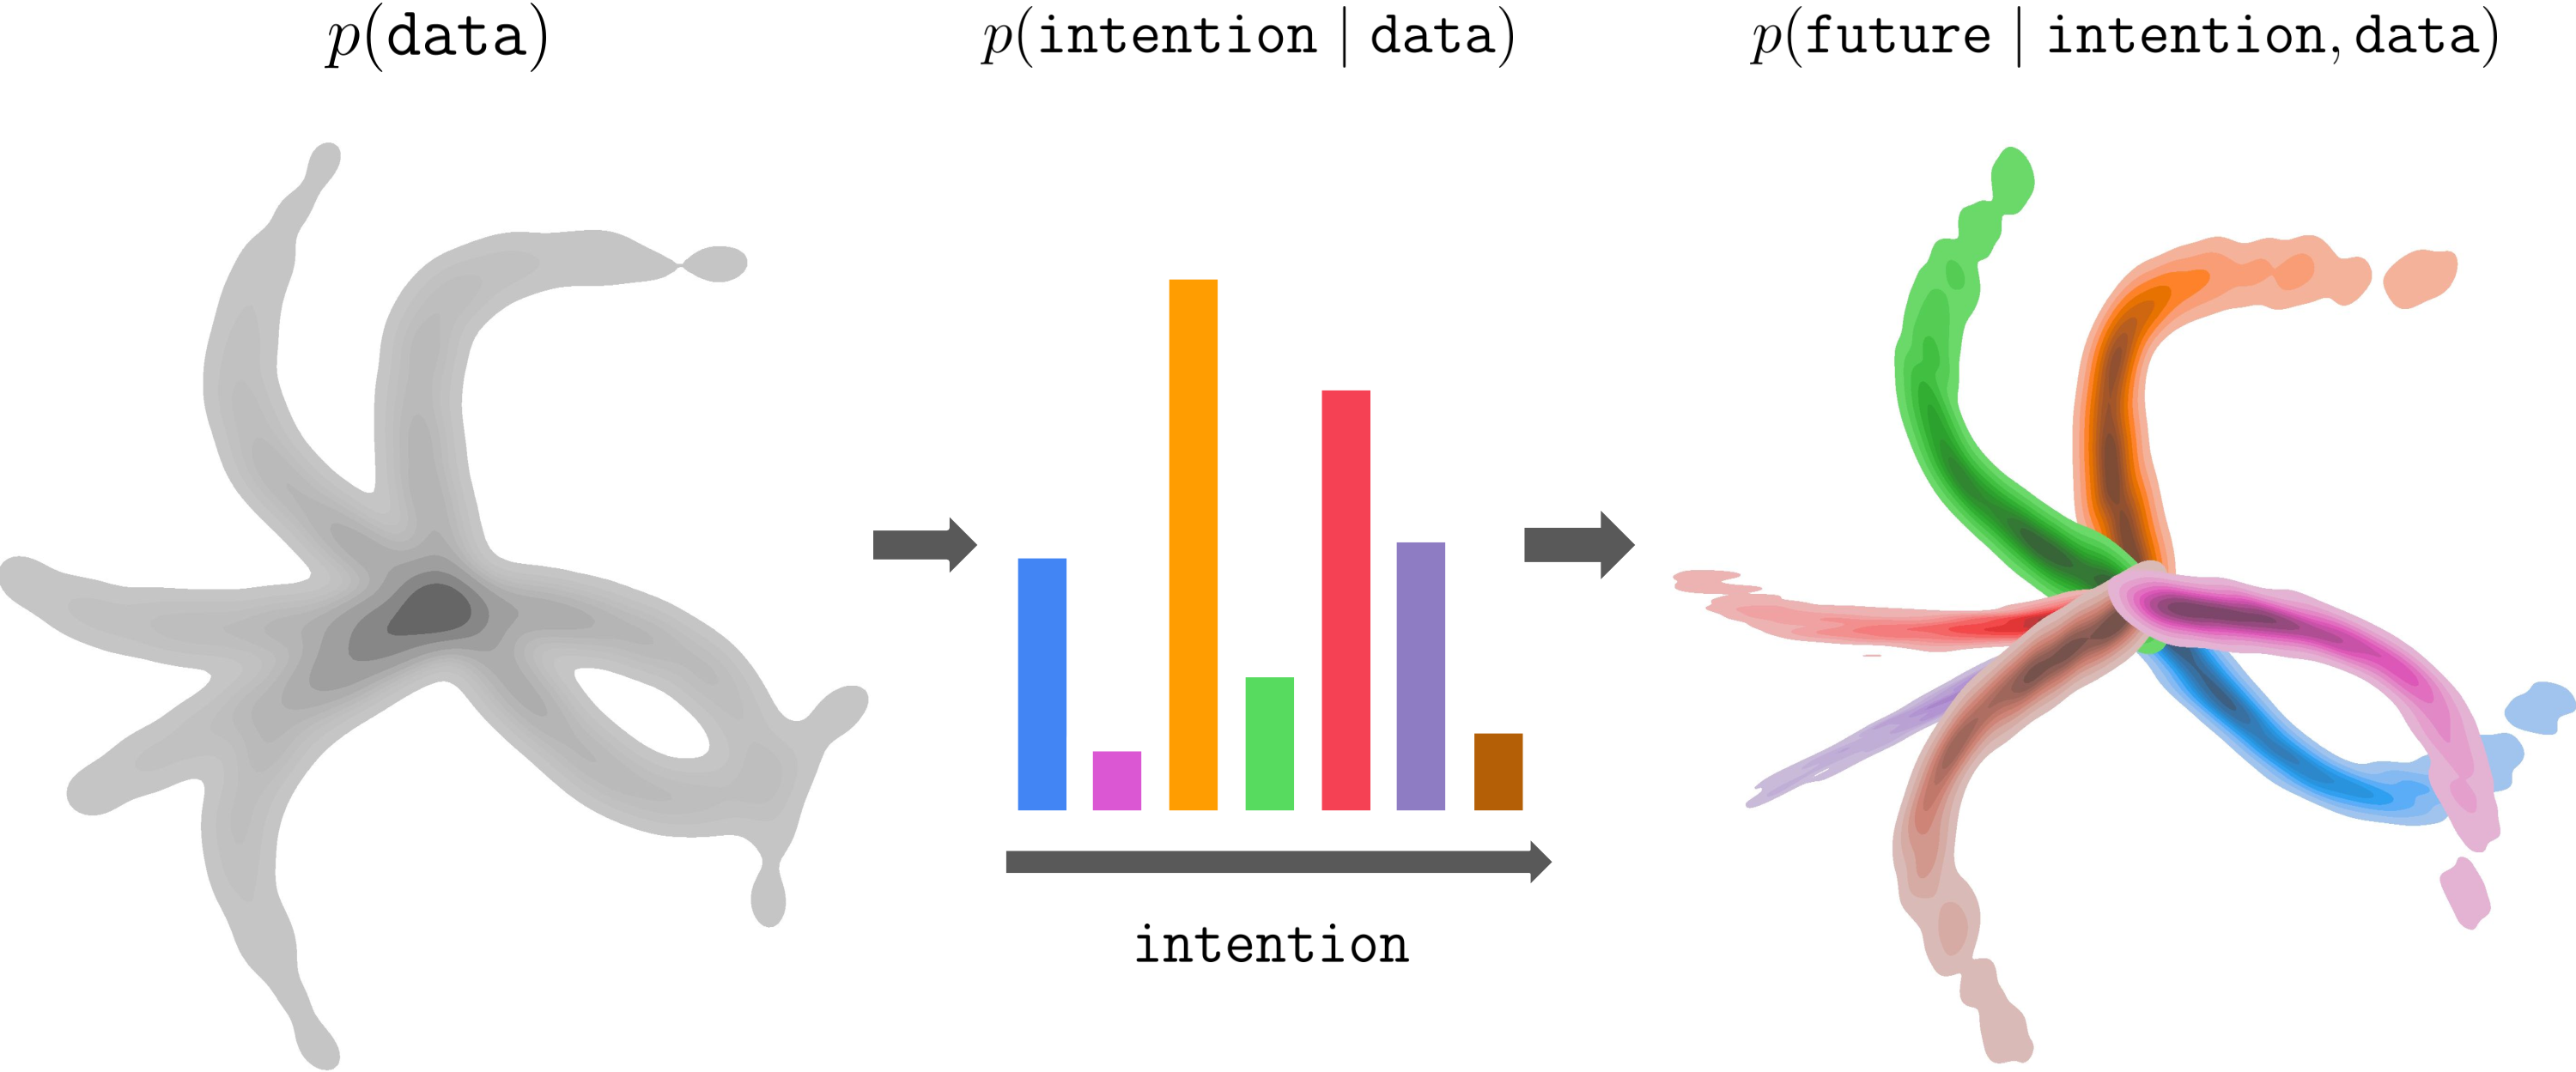

In [2]:
show_image(paths['InFOM overview image'], width=950)


## Slide 2 - Background And Motivation

**Presentation version**

This project builds on three nearby ideas:

- **Third-person imitation:** observation can help learning under viewpoint/domain shift.
- **Theory-of-mind-style modeling:** trajectories can reveal latent agent properties and behavior modes.
- **InFOM:** latent intentions can support reward-free pretraining and downstream offline RL.

The project twist is cross-view control: learn from observation-like data, then act from the controller's own observation stream.

**Report expansion notes**

The original proposal framed the project broadly as latent intent from observing others. The check-in narrowed the problem to third-person observation for first-person RL. The final implementation made this concrete in OGBench cube-single by constructing paired state/RGB bridge data and adapting InFOM so RGB and state views can share a latent interface.


## Slide 3 - InFOM In One Slide

**Presentation version**

InFOM is the base RL algorithm I adapted.

- It uses **reward-free trajectories** to learn latent intentions and a flow-style future occupancy model.
- It then uses **reward-labeled fine-tuning** to train the reward model, critic, and actor.
- In this project, I do not replace InFOM; I add a cross-modal bridge so the same control stack can consume RGB-derived latents during training and state latents at deployment.

**Report expansion notes**

The useful conceptual handle is: InFOM gives an intention-conditioned offline RL backbone. My project changes the observation interface around that backbone. The new question is whether state and third-person RGB streams can be aligned tightly enough that the actor still controls the environment from state-only observations.


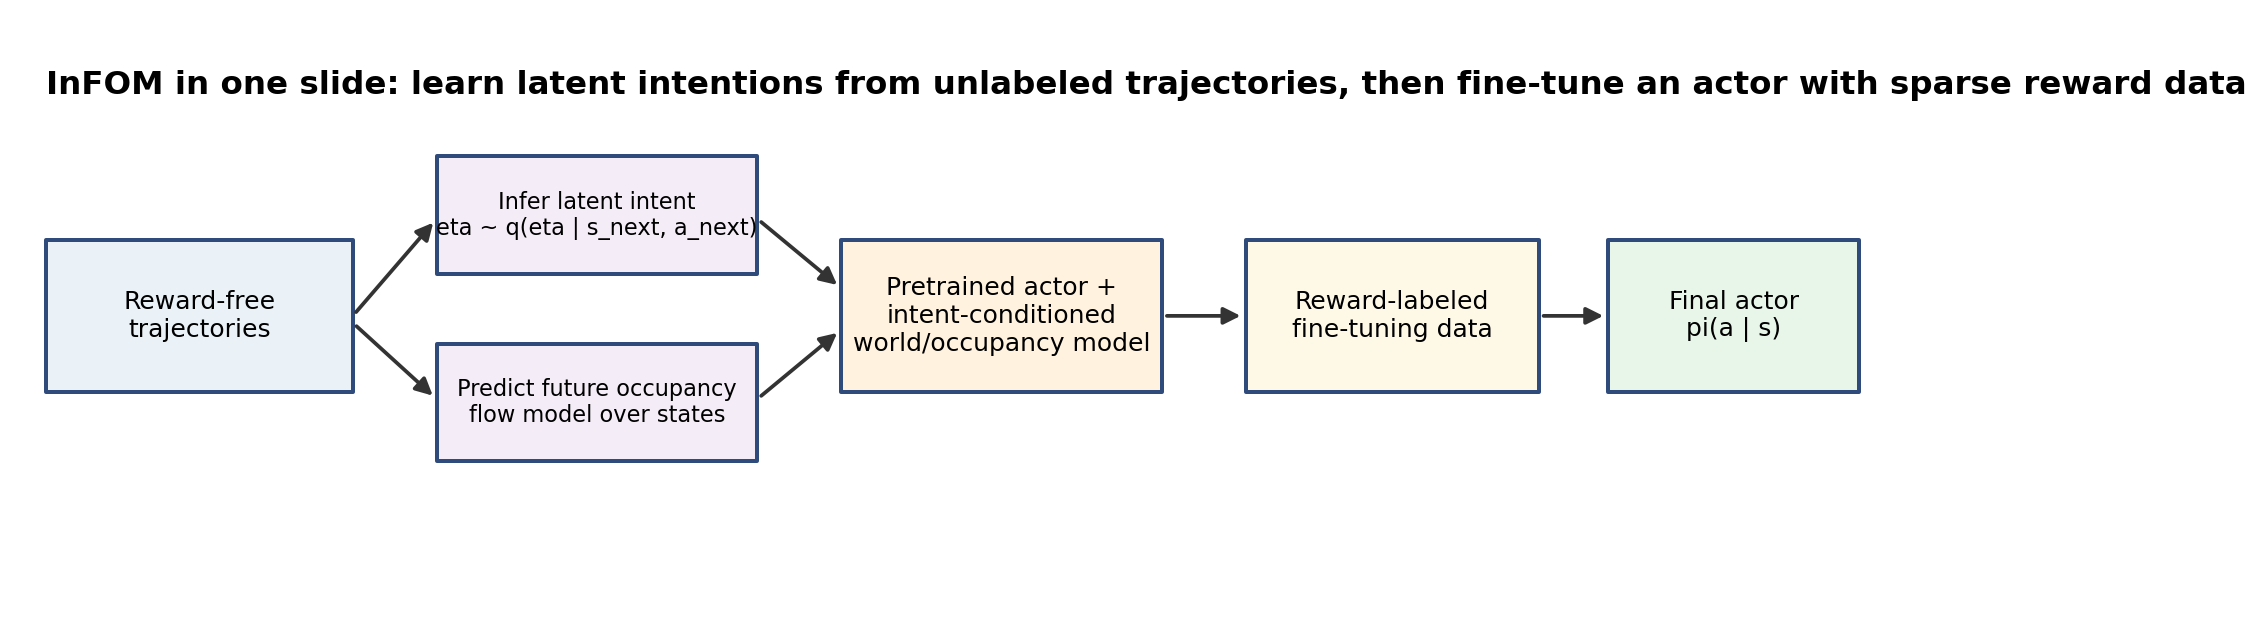

In [3]:
show_image(paths['InFOM brief pipeline'], width=980)


## Slide 4 - Problem Statement

**Presentation version**

**Problem:** learn an intent-conditioned control representation when the pretraining observation stream and deployment observation stream are different.

```text
Reward-free pretraining:  state + synchronized third-person RGB + actions
Reward-labeled FT:       RGB bridge stream + actions + rewards
Evaluation/deployment:   low-dimensional state only
```

This creates a cross-modal bottleneck: the policy has to survive the handoff from RGB-derived latents to state-derived latents.

**Report expansion notes**

The practical first phase uses the agent's own synchronized third-person view as an alignment bridge. This is not the full cross-agent setting, but it isolates the observation/control mismatch while keeping simulator and dataset risk manageable. The bridge dataset retains `qpos`, `qvel`, low-dimensional observations, actions, next observations, terminals, and synchronized RGB renders so transition alignment can be audited.


## Slide 5 - Concrete Interface Example

**Presentation version**

This is what one bridge transition looks like.

- The policy ultimately acts from a **28-D low-dimensional state observation**.
- The training bridge also stores a synchronized **64x64 RGB third-person frame**.
- The actor outputs a **5-D continuous action** controlling a UR5e arm and Robotiq gripper.
- The saved `qpos` and `qvel` are useful for replay/rendering and auditing, but the deployed policy input is the 28-D observation vector.

**Report expansion notes**

For cube-single, the low-dimensional observation combines arm joint positions and velocities, end-effector position/yaw, gripper opening/contact, and cube pose information. The action is relative end-effector control: x/y/z translation, yaw, and gripper opening. This concrete interface helps explain why state-distilled our method can be more control-relevant than a generic contrastive embedding.


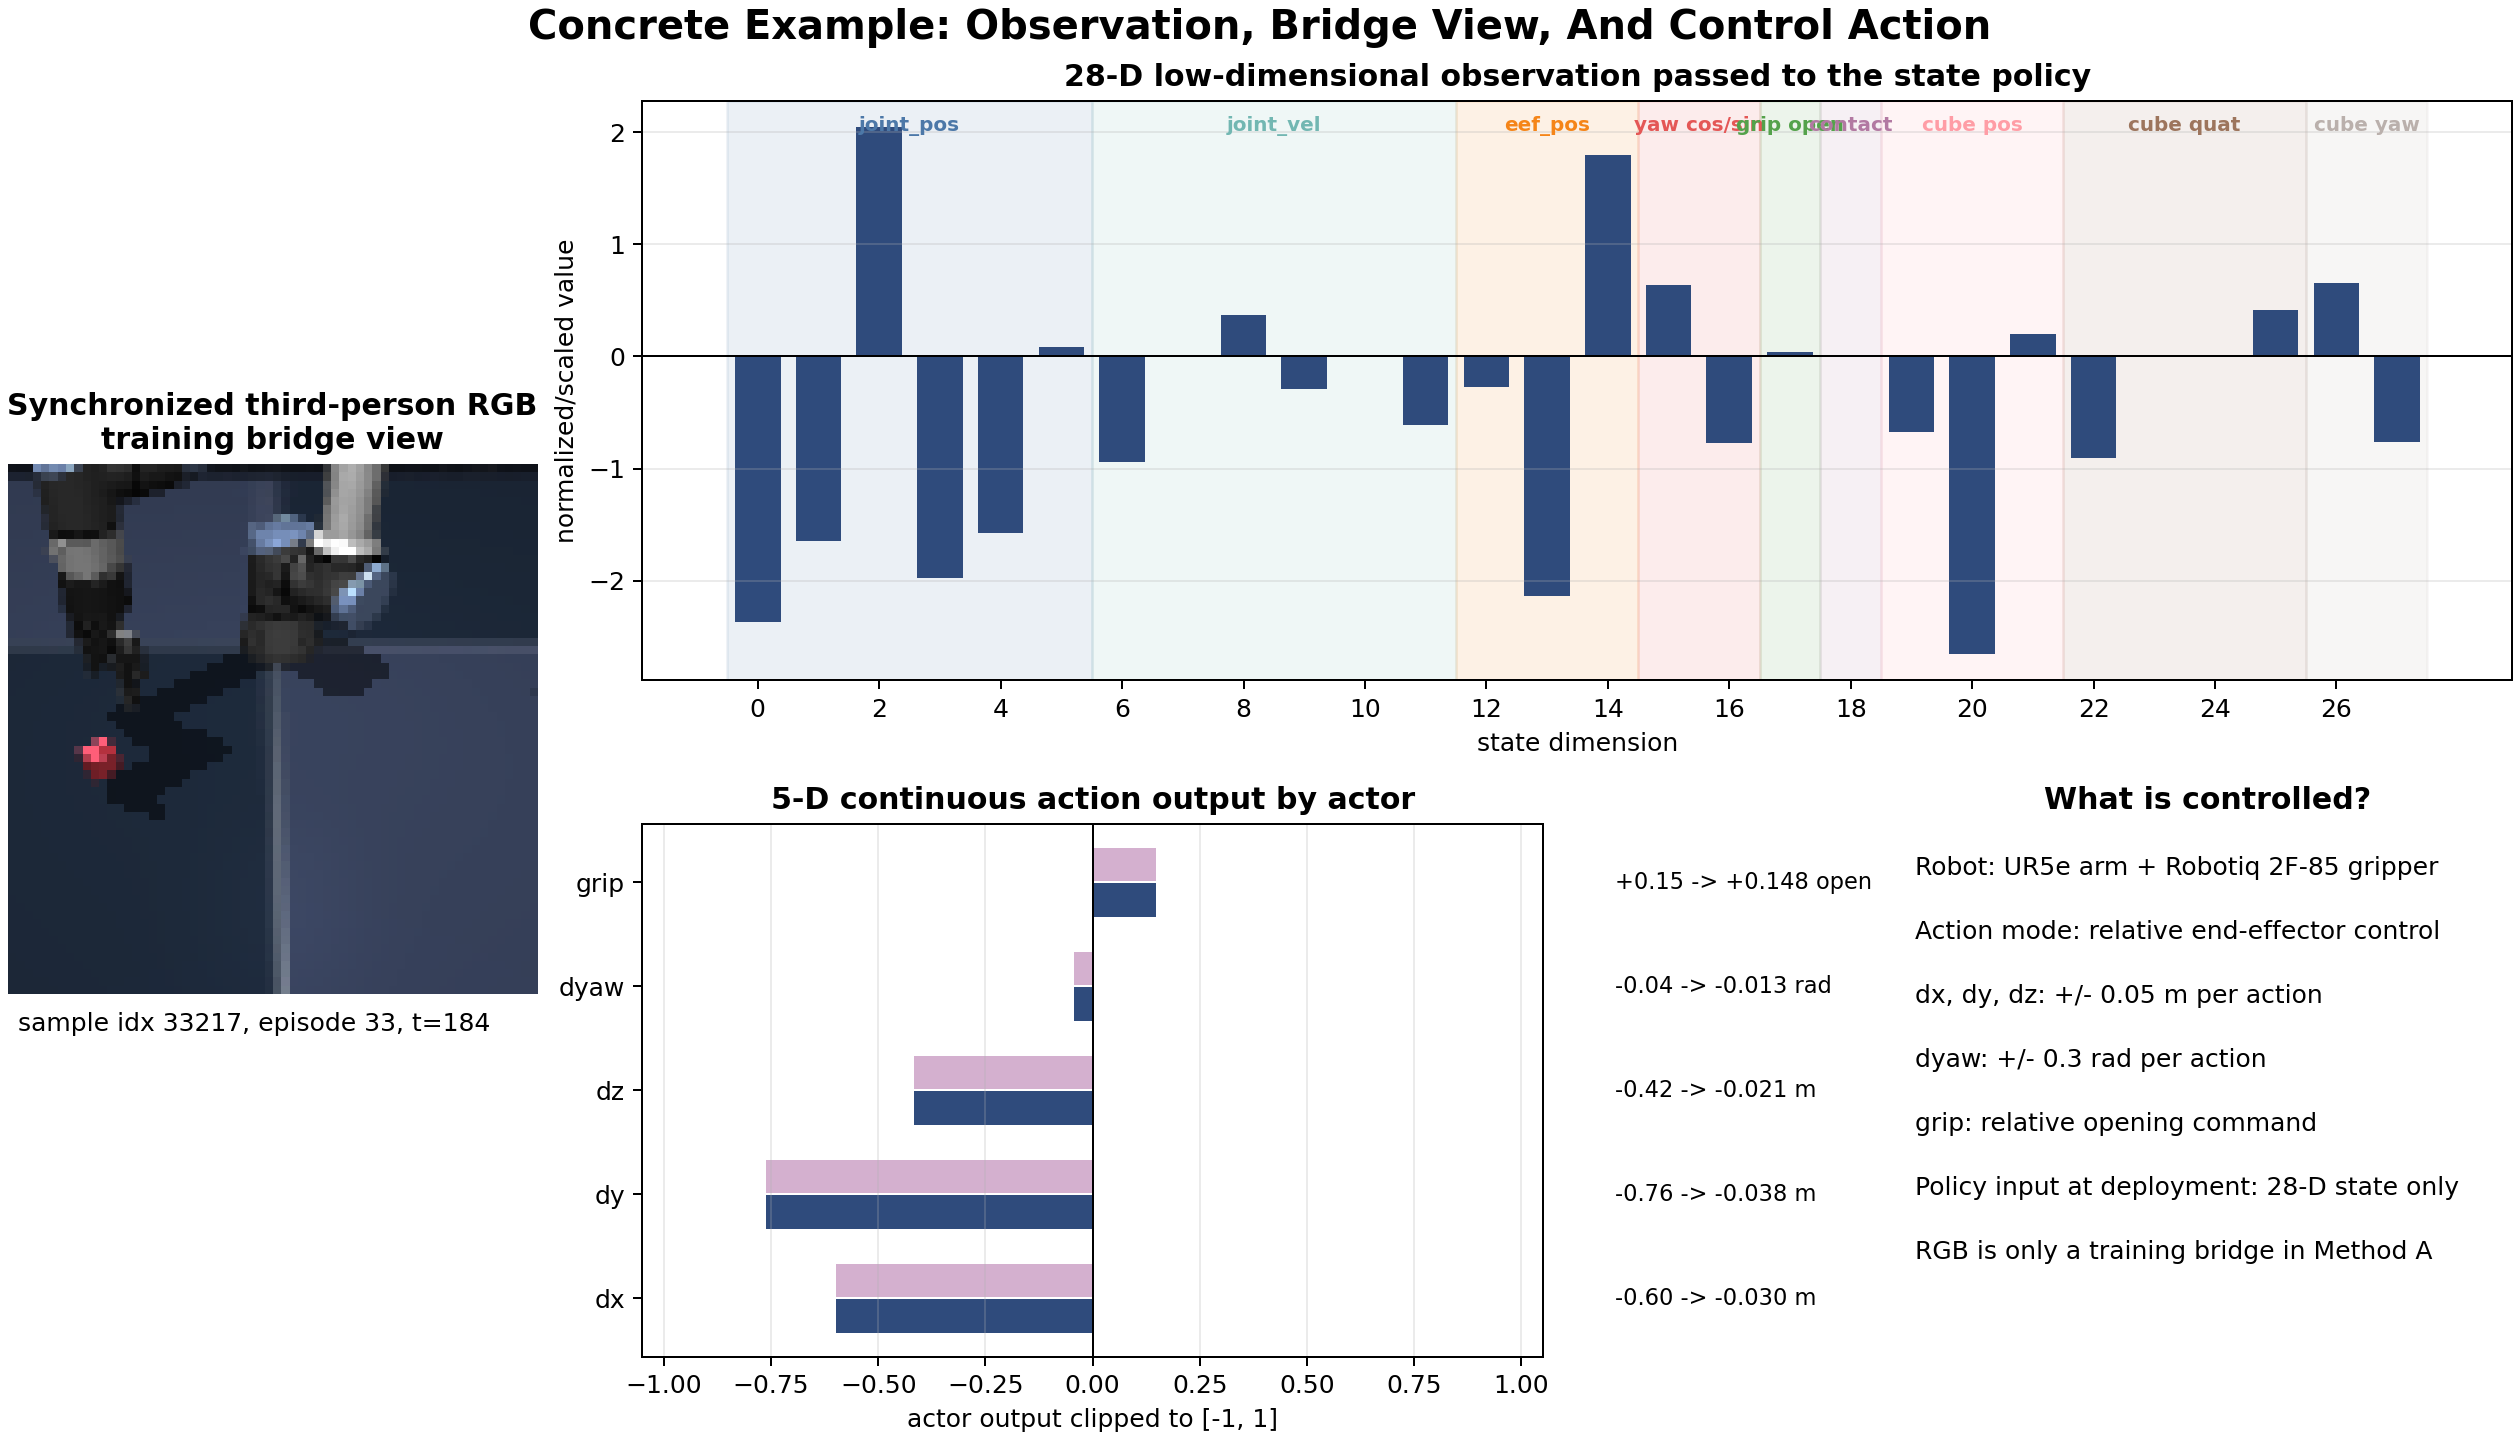

| Item | Dims | Meaning | Example values |
| --- | --- | --- | --- |
| joint_pos | 0-5 | UR5e arm joint positions | -2.37, -1.65, 2.05, -1.98, ... |
| joint_vel | 6-11 | UR5e arm joint velocities | -0.94, -0.00, 0.37, -0.29, ... |
| eef_pos | 12-14 | scaled end-effector position | -0.27, -2.14, 1.79 |
| yaw cos/sin | 15-16 | end-effector yaw angle as cos/sin | 0.64, -0.77 |
| grip open | 17-17 | scaled gripper opening | 0.040 |
| contact | 18-18 | gripper contact signal | 0.000 |
| cube pos | 19-21 | scaled cube position | -0.67, -2.65, 0.20 |
| cube quat | 22-25 | cube orientation quaternion | -0.91, -0.00, -0.00, 0.42 |
| cube yaw | 26-27 | cube yaw as cos/sin | 0.65, -0.76 |
| action | 0-4 | relative end-effector dx/dy/dz, yaw, gripper opening | -0.60, -0.76, -0.42, -0.04, 0.15 |

In [4]:
show_image(paths['Observation/action example'], width=980)
example_rows = read_csv(paths['State/action example table'])
show_table(example_rows, ['item', 'dims', 'meaning', 'example_values'], ['Item', 'Dims', 'Meaning', 'Example values'])


## Slide 6 - Hypotheses

**Presentation version**

1. **Bridge hypothesis:** paired state/RGB trajectories contain enough information for an RGB encoder to recover a state-like control latent.
2. **Intent-control hypothesis:** once the bridge is stable, the InFOM backbone can learn useful intent-conditioned dynamics and policies through that latent.
3. **Robustness hypothesis:** the main bottleneck is not whether behavior ever appears, but whether late fine-tuning preserves it under the paper reporting window.

**Report expansion notes**

The final evidence separates representation learning from control robustness. our method gives the clearest control signal because its latent is explicitly state-like. Method B remains useful as a negative ablation: strong cross-modal retrieval did not translate to strong control, so generic alignment is not enough.


## Slide 7 - Method: State-Distilled InFOM

**Presentation version**

The presentation focuses on **our method**, the best-performing bridge method.

| Component | What it does |
| --- | --- |
| Fixed state encoder | normalizes the 28-D low-dimensional observation |
| RGB bridge | `impala_small` encoder maps 64x64 third-person RGB into the same 28-D latent |
| Bridge loss | supervised RGB-to-state MSE on synchronized paired data |
| InFOM backbone | intention encoder, flow occupancy model, reward model, critic, actor |
| Evaluation | discard RGB and act from normalized state only |

**Report expansion notes**

Method B was implemented as a TCN/InfoNCE backup, but it is not a main presentation plot because the result is weak for control. Its role in the report is a negative ablation: retrieval alignment can be excellent while downstream control remains poor.


## Slide 8 - What Actually Runs

**Presentation version**

our method runs as a state-distilled bridge around the original InFOM training loop.

1. **Bridge data:** paired low-dimensional state, third-person RGB, actions, rewards, next observations.
2. **Bridge learning:** train RGB latents to match normalized state latents.
3. **Intent pretraining:** train the InFOM flow/intent losses using the state-like latent interface.
4. **Fine-tuning:** train reward, critic, actor, and flow components on reward-labeled bridge data.
5. **Deployment:** evaluate with state-only input, no RGB.

**Report expansion notes**

The key design choice is deliberately conservative: our method makes RGB imitate the state representation rather than asking a contrastive embedding to discover every control-relevant factor implicitly. That appears to matter for downstream control.


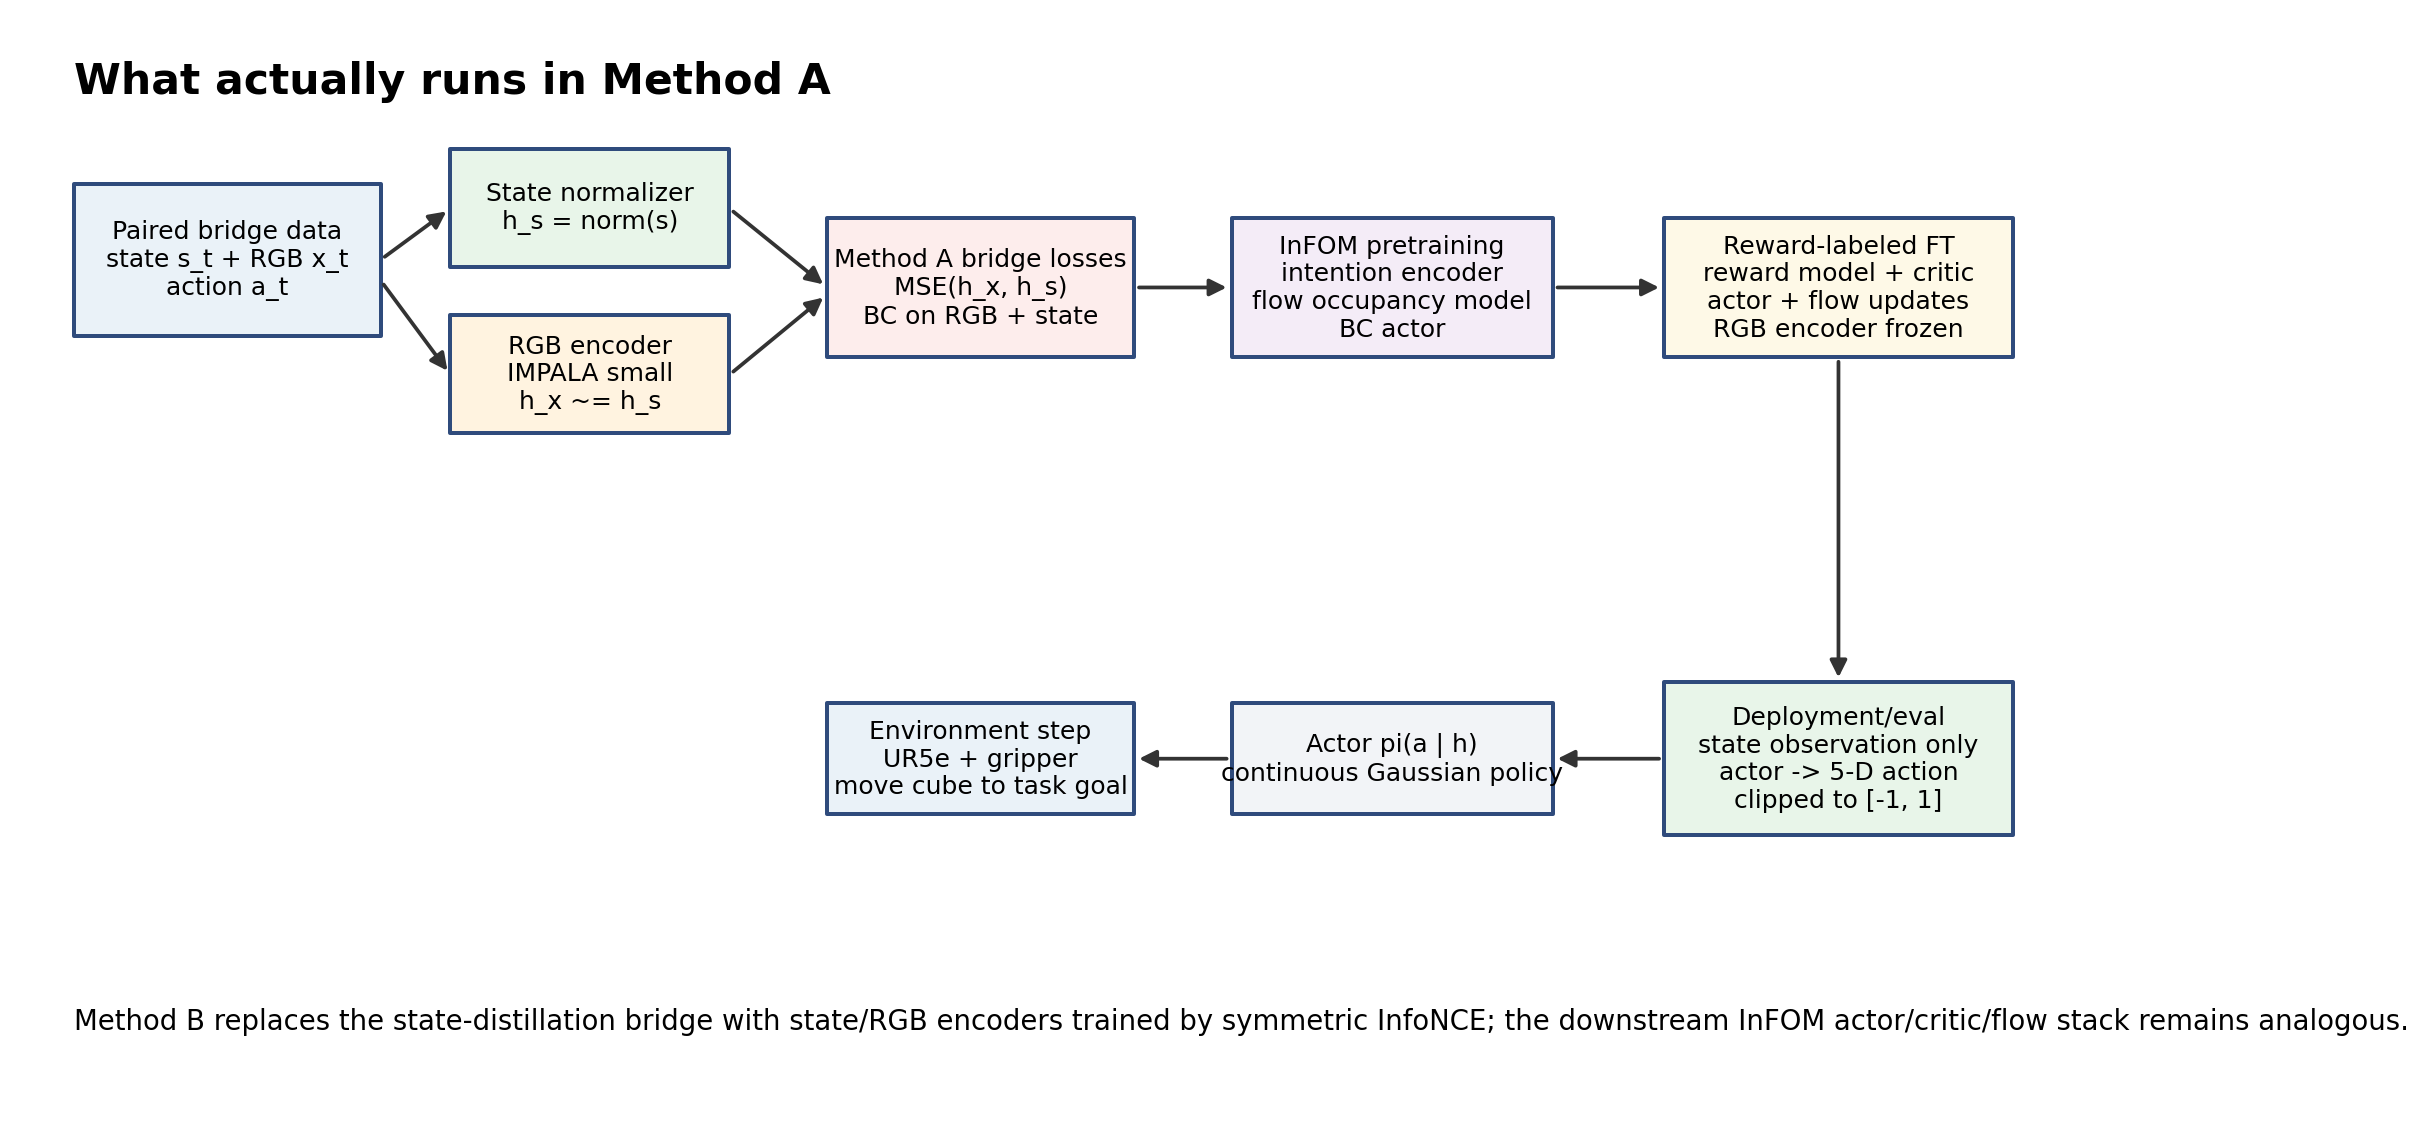

| Piece | Specifics |
| --- | --- |
| Environment | OGBench cube-single manipulation; sparse task success based on cube reaching target |
| Robot/action | UR5e + Robotiq gripper; 5-D relative end-effector dx/dy/dz, yaw, gripper opening |
| Policy input at eval | 28-D low-dimensional observation; no RGB at deployment |
| our method bridge | impala_small RGB encoder -> 28-D pseudo-state; MSE to normalized state |
| InFOM backbone | intention encoder, flow occupancy/vector field, reward model, critic, actor |
| Method B bridge | state/RGB encoders with symmetric InfoNCE; strong retrieval but weak control |

In [5]:
show_image(paths['our method algorithm pipeline'], width=1000)
method_detail_rows = [
    {'piece': 'Environment', 'specifics': 'OGBench cube-single manipulation; sparse task success based on cube reaching target'},
    {'piece': 'Robot/action', 'specifics': 'UR5e + Robotiq gripper; 5-D relative end-effector dx/dy/dz, yaw, gripper opening'},
    {'piece': 'Policy input at eval', 'specifics': '28-D low-dimensional observation; no RGB at deployment'},
    {'piece': 'our method bridge', 'specifics': 'impala_small RGB encoder -> 28-D pseudo-state; MSE to normalized state'},
    {'piece': 'InFOM backbone', 'specifics': 'intention encoder, flow occupancy/vector field, reward model, critic, actor'},
    {'piece': 'Method B bridge', 'specifics': 'state/RGB encoders with symmetric InfoNCE; strong retrieval but weak control'},
]
show_table(method_detail_rows, ['piece', 'specifics'], ['Piece', 'Specifics'])


## Slide 9 - Metrics Beyond Success Rate

**Presentation version**

Success rate is the headline OGBench metric, but it is not enough here.

| Metric | Role in this project |
| --- | --- |
| Paper-window success | Conservative late-training success, averaged over 1.4M/1.45M/1.5M steps |
| Paper-window success | Late-training performance under the paper-style reporting rule |
| Best success | Diagnostic for whether the method ever finds useful behavior |
| Collapse = best - final | Measures late fine-tuning instability |
| Episode length | Helps distinguish faster successes from full-horizon failures |
| RGB-to-state alignment loss | Checks whether the third-person RGB bridge learned the state-like latent |
| RGB-state action MSE/cosine | Checks whether our method produces consistent actions from RGB and state latents |
| Demo summaries | Aggregate qualitative context only; current saved videos are not individually success-labeled |

**Report expansion notes**

The main evidence table should report mean plus spread when available, and keep best-checkpoint results separate from paper-style metrics. Best success is not a fair headline metric, but it is important because several runs learn a behavior and then lose it. The current demo renderer stores aggregate success over 10 episodes but does not label each saved video, so videos should not be used as proof of success unless regenerated with per-video success metadata.


## Slide 10 - Main Empirical Signals

**Presentation version**

The final result is **promising but unstable**.

- Our method is the best-supported bridge method in the evidence package.
- Our method task1 over 5 seeds: paper-window success `0.191`, mean best success `0.656`, best seed `0.800`.
- Our method task4 over 6 seeds: paper-window success `0.199`, mean best success `0.477`, best seed `0.660`.
- The gap between best and paper-window success is the main story: the method often finds behavior, then late fine-tuning collapses.

**Report expansion notes**

Do not present this as beating InFOM or solving the benchmark. The right claim is that the state-distilled bridge can produce real control signal under observation mismatch, while the evidence also reveals substantial instability and task dependence.


In [6]:
summary = read_csv(paths['our method presentation summary'])
show_table(
    summary,
    ['task', 'n_runs', 'paper_window_mean', 'paper_window_std', 'best_mean', 'best_max', 'paper_reported_infom'],
    ['Task', 'Runs', 'Paper-window mean', 'Std', 'Best mean', 'Best seed', 'Paper InFOM'],
)


| Task | Runs | Paper-window mean | Std | Best mean | Best seed | Paper InFOM |
| --- | --- | --- | --- | --- | --- | --- |
| 1.000 | 5.000 | 0.191 | 0.297 | 0.656 | 0.800 | 0.925 |
| 2.000 | 2.000 | 0.013 | 0.019 | 0.170 | 0.240 | 0.784 |
| 3.000 | 2.000 | 0.123 | 0.174 | 0.360 | 0.360 | 0.564 |
| 4.000 | 6.000 | 0.199 | 0.220 | 0.477 | 0.660 | 0.915 |
| 5.000 | 2.000 | 0.017 | 0.024 | 0.480 | 0.560 | 0.700 |

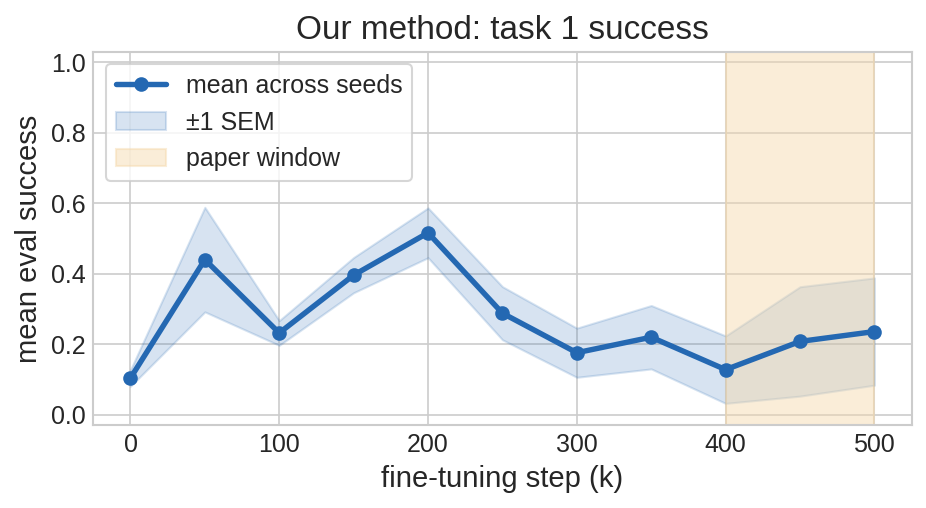

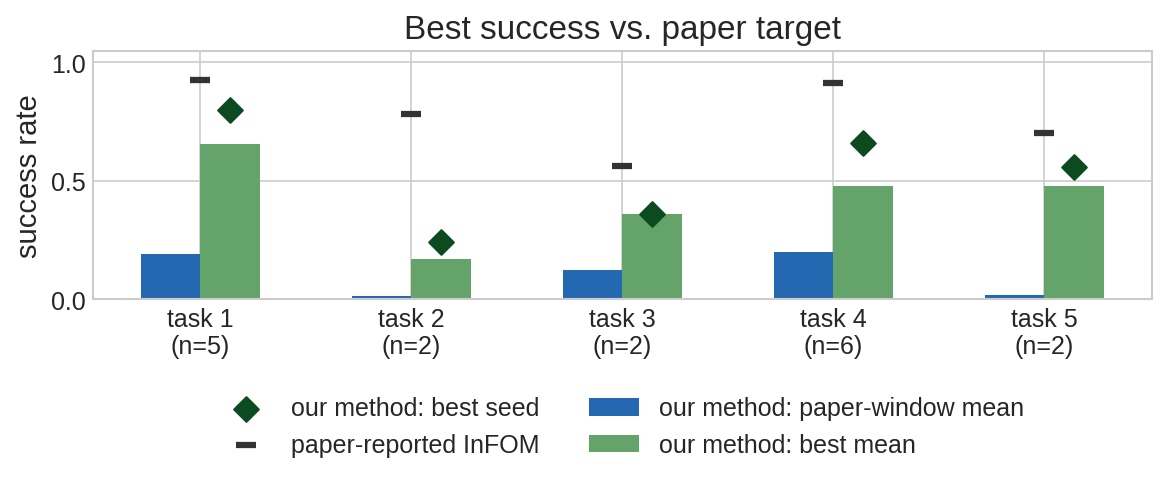

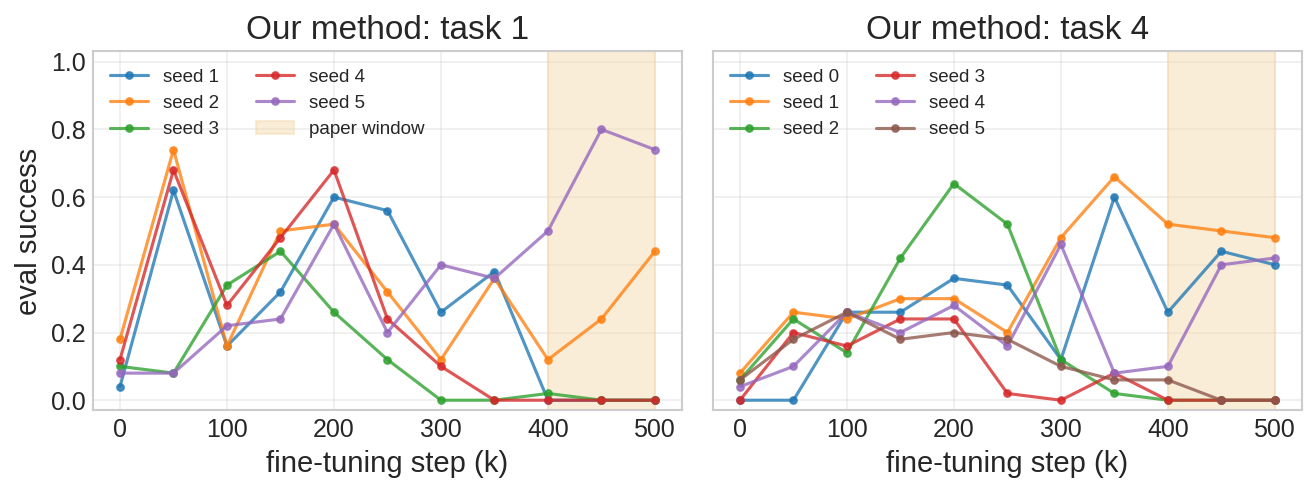

In [7]:
show_image(paths['our method task1 mean success curve'], width=700)
show_image(paths['our method best vs paper plot'], width=720)
show_image(paths['our method success curves'], width=760)


## Slide 11 - What The Pieces Learned

**Presentation version**

The useful story is component-level:

- **Bridge learned:** RGB-to-state alignment loss falls, and the actor's RGB/state action cosine rises during pretraining. Action cosine is the mean cosine similarity between the actor action from the RGB-derived latent and the actor action from the matched true-state latent.
- **Pretraining trace caveat:** the checkpoint used for fine-tuning completed 1M pretraining updates, but the locally synced metric CSV for this diagnostic plot only reaches about 608k updates.
- **InFOM learned:** flow occupancy and KL-style intent losses drop after the bridge warmup.
- **Control emerged:** several our method seeds reach high best success.
- **But robustness failed:** many successful mid-run policies collapse by the paper reporting window.

**Report expansion notes**

This is stronger than a single success-rate plot because it shows where the pipeline is working and where it is breaking. The bridge and InFOM pieces learn useful structure, but final offline fine-tuning is unstable.


| Metric | Early mean | Late mean | Min | Max |
| --- | --- | --- | --- | --- |
| validation/align/align_loss | 0.620 | 0.396 | 0.267 | 0.690 |
| validation/actor_modality/action_cos_rgb_state | 0.683 | 0.917 | 0.632 | 0.970 |
| validation/actor_modality/action_mse_rgb_state | 0.000 | 0.012 | 0.000 | 0.035 |
| validation/flow_occupancy/flow_matching_loss | 0.024 | 0.008 | 0.008 | 0.039 |
| validation/flow_occupancy/neg_elbo_loss | 0.201 | 0.010 | 0.009 | 0.208 |
| validation/flow_occupancy/kl_loss | 3.545 | 0.024 | 0.007 | 3.685 |
| validation/loss/infom_pretraining_loss | 5.282 | 4.658 | 4.643 | 5.319 |

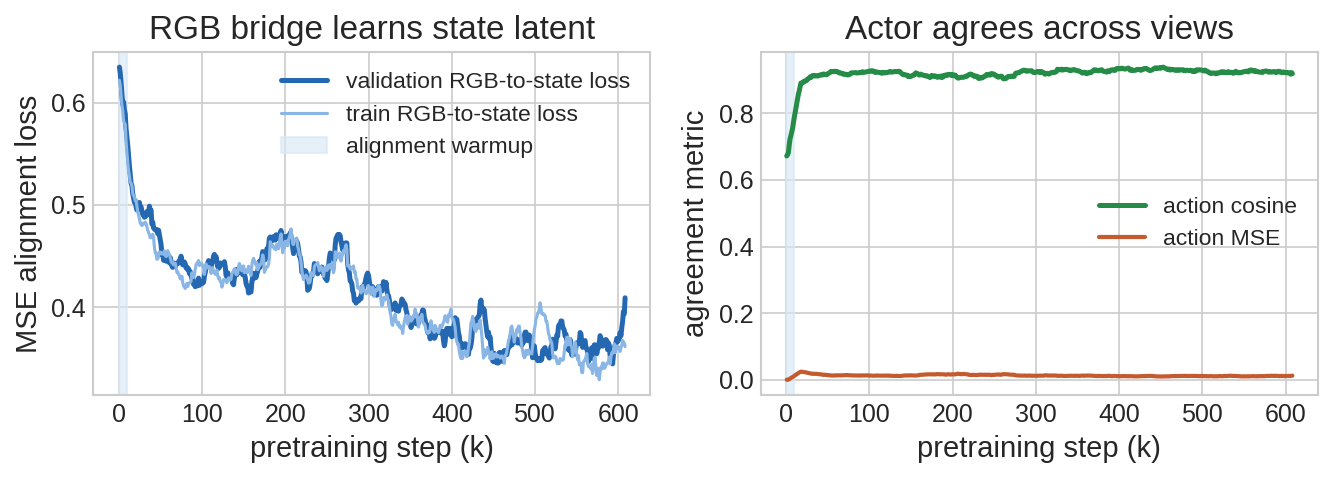

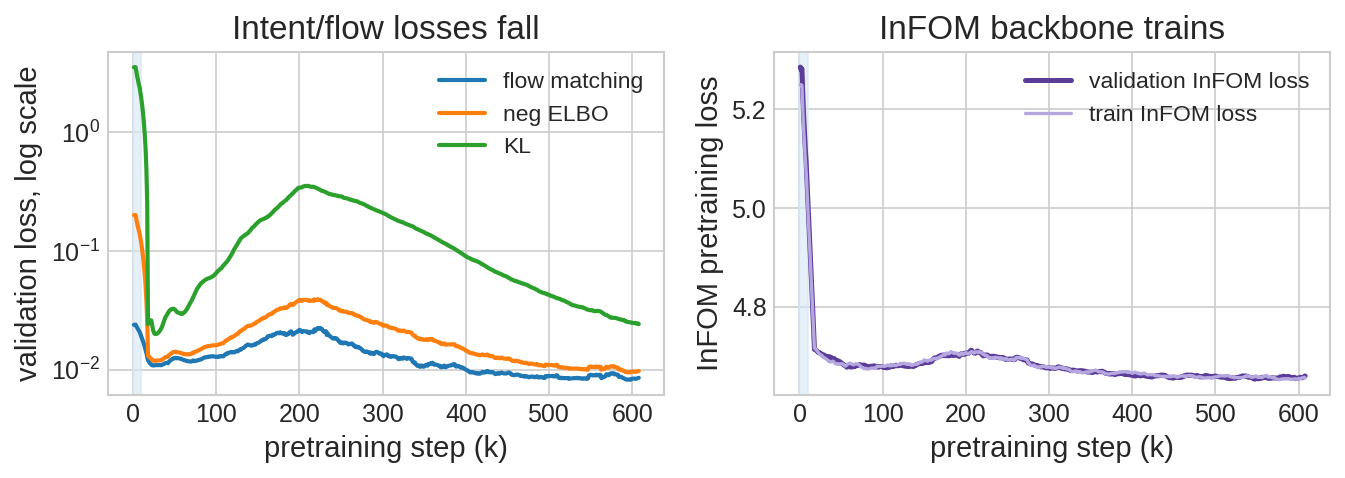

In [8]:
pre_summary = read_csv(paths['our method pretraining summary'])
show_table(
    pre_summary,
    ['metric', 'first_10_mean', 'last_10_mean', 'min', 'max'],
    ['Metric', 'Early mean', 'Late mean', 'Min', 'Max'],
)
show_image(paths['our method bridge learning plot'], width=760)
show_image(paths['our method intent learning plot'], width=760)


## Slide 12 - Demo Caveat

**Presentation version**

I would not include the current MP4/GIF demos in the 5-minute presentation as success evidence.

- The summary JSON reports aggregate success across 10 eval episodes.
- The saved videos are only the first two rendered episodes and are not individually labeled as success/failure.
- If the visible videos do not clearly show success, use the metric plots instead.
- To use demos in slides, regenerate them with per-video success labels or choose explicitly successful rollouts.

**Report expansion notes**

The demo summaries are still useful as provenance: task4 seed1 best reports aggregate success 0.7 over 10 eval episodes, while task4 seed1 final reports 0.5. But without per-video labels, the current videos should be treated as debugging artifacts, not presentation evidence.


In [9]:
demos = read_csv(paths['Demo summary'])
show_table(
    demos,
    ['demo', 'episodes', 'success_rate', 'mean_return', 'mean_length', 'summary_path'],
    ['Demo summary', 'Eval episodes', 'Aggregate success', 'Mean return', 'Mean length', 'Summary'],
)

display(Markdown(
    '**Presentation decision:** do not embed the current demo videos as success evidence. '
    'The renderer saved two videos per checkpoint, but the summary only gives aggregate success over 10 eval episodes. '
    'Regenerate demos with per-video success labels before using them in slides.'
))


| Demo summary | Eval episodes | Aggregate success | Mean return | Mean length | Summary |
| --- | --- | --- | --- | --- | --- |
| task1_seed1_best | 10.00 | 0.700 | -107.4 | 108.1 | output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis/demos/task1_seed1_best/cross_modal_state_distilled_infom_bridge-cube-single-play-singletask-task1-v0_seed1_summary.json |
| task1_seed1_final | 10.00 | 0.000 | -200.0 | 200.0 | output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis/demos/task1_seed1_final/cross_modal_state_distilled_infom_bridge-cube-single-play-singletask-task1-v0_seed1_summary.json |
| task4_seed1_best | 10.00 | 0.700 | -136.2 | 136.9 | output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis/demos/task4_seed1_best/cross_modal_state_distilled_infom_bridge-cube-single-play-singletask-task4-v0_seed1_summary.json |
| task4_seed1_final | 10.00 | 0.500 | -151.7 | 152.2 | output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis/demos/task4_seed1_final/cross_modal_state_distilled_infom_bridge-cube-single-play-singletask-task4-v0_seed1_summary.json |

**Presentation decision:** do not embed the current demo videos as success evidence. The renderer saved two videos per checkpoint, but the summary only gives aggregate success over 10 eval episodes. Regenerate demos with per-video success labels before using them in slides.

## Slide 13 - Contributions

**Presentation version**

The project contributions are mainly methodological and empirical:

1. A sharper formulation of observation-derived intent under cross-view control mismatch.
2. A bridge-data protocol for paired low-dimensional state and third-person RGB in OGBench cube-single.
3. A state-distilled InFOM method that maps RGB into the state-like latent used for control.
4. An evidence package that separates bridge learning, InFOM intent learning, control success, collapse, and provenance.
5. A conservative empirical finding: state-like bridges can produce control signal, but final fine-tuning is unstable.

**Report expansion notes**

The framing is important: the contribution is not a new state-of-the-art benchmark result. It is a controlled implementation and analysis of a difficult alignment problem inside offline RL. The negative Method B result remains useful in the report because it shows cross-modal retrieval alignment is not the same as control utility.


## Slide 14 - Limitations And Final Takeaway

**Presentation version**

Limitations:

- Results are not a clean win and have high seed variance.
- Fine-tuning collapse makes paper-window metrics much weaker than best checkpoints.
- The bridge uses the agent's own synchronized third-person view, not true cross-agent transfer.
- Exact paper replication is not fully established because fine-tuning dataset provenance remains a caveat.

**Final takeaway:** state-distilled cross-modal intent learning is feasible enough to produce real control signals, but robust transfer needs better late fine-tuning stability.

**Report expansion notes**

The strongest next experiment is not more Method B scaling. It is our method anti-collapse work: lower FT learning rate, stronger conservative/BC regularization, checkpoint selection, reward/critic stabilization, and explicit reporting of paper-window versus best-checkpoint performance.


In [10]:
claims = read_csv(paths['Claim readiness'])
for row in claims:
    for key, value in list(row.items()):
        if isinstance(value, str):
            row[key] = value.replace(SOURCE_METHOD_LABEL, 'our method').replace(SOURCE_METHOD_LABEL.lower(), 'our method')
show_table(
    claims,
    ['claim', 'status', 'gap_or_caveat'],
    ['Claim', 'Status', 'Gap or caveat'],
)


| Claim | Status | Gap or caveat |
| --- | --- | --- |
| our method is the primary bridge method to scale. | supported | Needs more our method seeds on task4 and one additional high-target task before broader claims. |
| Method B contrastive/TCN alignment is sufficient for control transfer. | not supported | This argues alignment alone is insufficient; do not spend remaining time scaling B unless new B512 completion changes this materially. |
| Late FT collapse is a central limitation. | supported | Need distinguish instability from dataset/task mismatch; report best checkpoint only as diagnostic, not headline. |
| Exact paper replication has been fully established. | not established | Do not claim paper-level replication; use original InFOM as contextual baseline only. |

## Appendix - Report Expansion Bank

**Motivation paragraph seed**

A central challenge in RL is learning behavioral abstractions that support sparse-reward, long-horizon, and transfer settings. This project studies whether observation can provide those abstractions in a way that is useful for control, not only prediction.

**Problem statement paragraph seed**

The core technical problem is a cross-modal handoff: reward-free observation data include synchronized state/RGB views, reward-labeled fine-tuning uses a bridge stream, and deployment uses state-only control. The learned latent must therefore be both modality-aligned and action-relevant.

**Hypotheses paragraph seed**

The project tested whether paired observations can align RGB and state latents, whether InFOM can learn intent-conditioned control through that aligned interface, and whether diagnostics such as action agreement and late collapse explain the control outcome. The evidence supports bridge learning and partially supports control transfer for our method, but identifies collapse as the major failure mode.

**Theory/method paragraph seed**

InFOM provides the base structure: reward-free pretraining learns an intention-conditioned flow occupancy model, then reward-labeled fine-tuning trains reward, critic, and actor components. our method inserts a state-distilled RGB bridge into this structure so third-person RGB can be mapped into the same state-like latent used for deployment.

**Empirical results paragraph seed**

The empirical evidence is mixed. our method produces real downstream signal, including task1 seed5 with paper-window success 0.68 and best success 0.80, and task4 seed0/1 with paper-window success 0.37/0.50. However, many runs collapse by the final checkpoint, so the report should emphasize both best-checkpoint discovery and paper-window instability.


## Appendix - Artifact References

Primary local evidence used in this notebook:

- `docs/proposal.pdf` and `docs/check-in.pdf` for original motivation and timeline.
- `docs/design/phase1-self-third-person-bridge.md` for the bridge formulation.
- `cross_modal_state_distilled_infom_class_project.md` for our method/B implementation intent.
- `output/jupyter-notebook/method-b-ft-collapse-analysis.ipynb` for evidence aggregation.
- `output/jupyter-notebook/artifacts/method-b-ft-collapse-analysis/` for raw CSVs, run summaries, logs, and demos.
- `output/jupyter-notebook/artifacts/final-project-presentation/` for presentation-specific our method plots.
- `runs/reports/ogbench_bridge/` and `runs/reports/ogbench_paper_repro/` for earlier matched-run and replication caveats.

Linear context was requested but connector tools were unavailable in this session, so this notebook intentionally uses repo-local artifacts as the source of truth.
